In [1]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression,Ridge, Lasso 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn import metrics 
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
data = pd.read_csv('bangalore_house_prices.csv', sep=',')
data.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_type,Availability,location
0,3,2.0,150.0,1672.0,3,8971.291866,Super built-up Area,Ready To Move,Whitefield
1,3,3.0,149.0,1750.0,3,8514.285714,Built-up Area,Ready To Move,Whitefield
2,3,2.0,150.0,1750.0,3,8571.428571,Super built-up Area,Ready To Move,Whitefield
3,2,2.0,40.0,1250.0,2,3200.000000,Super built-up Area,Ready To Move,Whitefield
4,2,2.0,83.0,1200.0,2,6916.666667,Plot Area,Ready To Move,Whitefield


In [3]:
df = data.copy()
df.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_type,Availability,location
0,3,2.0,150.0,1672.0,3,8971.291866,Super built-up Area,Ready To Move,Whitefield
1,3,3.0,149.0,1750.0,3,8514.285714,Built-up Area,Ready To Move,Whitefield
2,3,2.0,150.0,1750.0,3,8571.428571,Super built-up Area,Ready To Move,Whitefield
3,2,2.0,40.0,1250.0,2,3200.000000,Super built-up Area,Ready To Move,Whitefield
4,2,2.0,83.0,1200.0,2,6916.666667,Plot Area,Ready To Move,Whitefield


In [4]:
df.shape

(7120, 9)

In [5]:
columns_names = df.columns.tolist()
columns_names

['bath',
 'balcony',
 'price',
 'total_sqft_int',
 'bhk',
 'price_per_sqft',
 'area_type',
 'Availability',
 'location']

In [6]:
df.isnull().sum()

bath              0
balcony           0
price             0
total_sqft_int    0
bhk               0
price_per_sqft    0
area_type         0
Availability      0
location          0
dtype: int64

In [7]:
df1 = df[['bath', 'balcony', 'total_sqft_int', 'bhk']]
df1.head()

,bath,balcony,total_sqft_int,bhk
0,3,2.0,1672.0,3
1,3,3.0,1750.0,3
2,3,2.0,1750.0,3
3,2,2.0,1250.0,2
4,2,2.0,1200.0,2


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bath            7120 non-null   int64  
 1   balcony         7120 non-null   float64
 2   total_sqft_int  7120 non-null   float64
 3   bhk             7120 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 222.6 KB


In [9]:
df1.describe()

,bath,balcony,total_sqft_int,bhk
count,7120.000000,7120.000000,7120.000000,7120.000000
mean,2.390871,1.572759,1479.729806,2.465169
std,0.876822,0.770583,913.779769,0.841520
min,1.000000,0.000000,350.000000,1.000000
25%,2.000000,1.000000,1100.000000,2.000000
50%,2.000000,2.000000,1255.000000,2.000000
75%,3.000000,2.000000,1640.250000,3.000000
max,9.000000,3.000000,30400.000000,9.000000


In [10]:
df1.corr()

,bath,balcony,total_sqft_int,bhk
bath,1.000000,0.283192,0.653435,0.882461
balcony,0.283192,1.000000,0.200648,0.269511
total_sqft_int,0.653435,0.200648,1.000000,0.647485
bhk,0.882461,0.269511,0.647485,1.000000


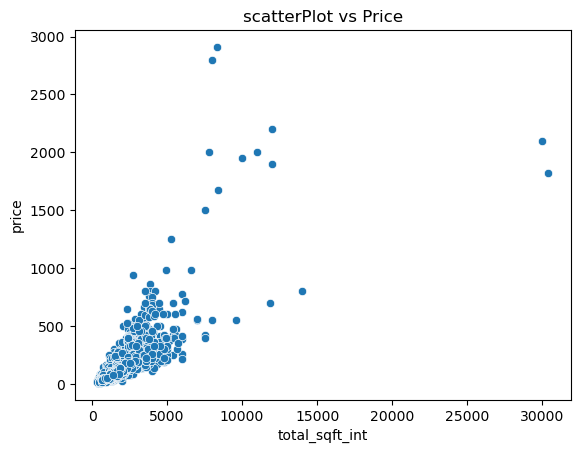

In [11]:
sns.scatterplot(x='total_sqft_int', y='price', data=df)
plt.title('scatterPlot vs Price')
plt.savefig('Scatter_plot.png')
plt.show()

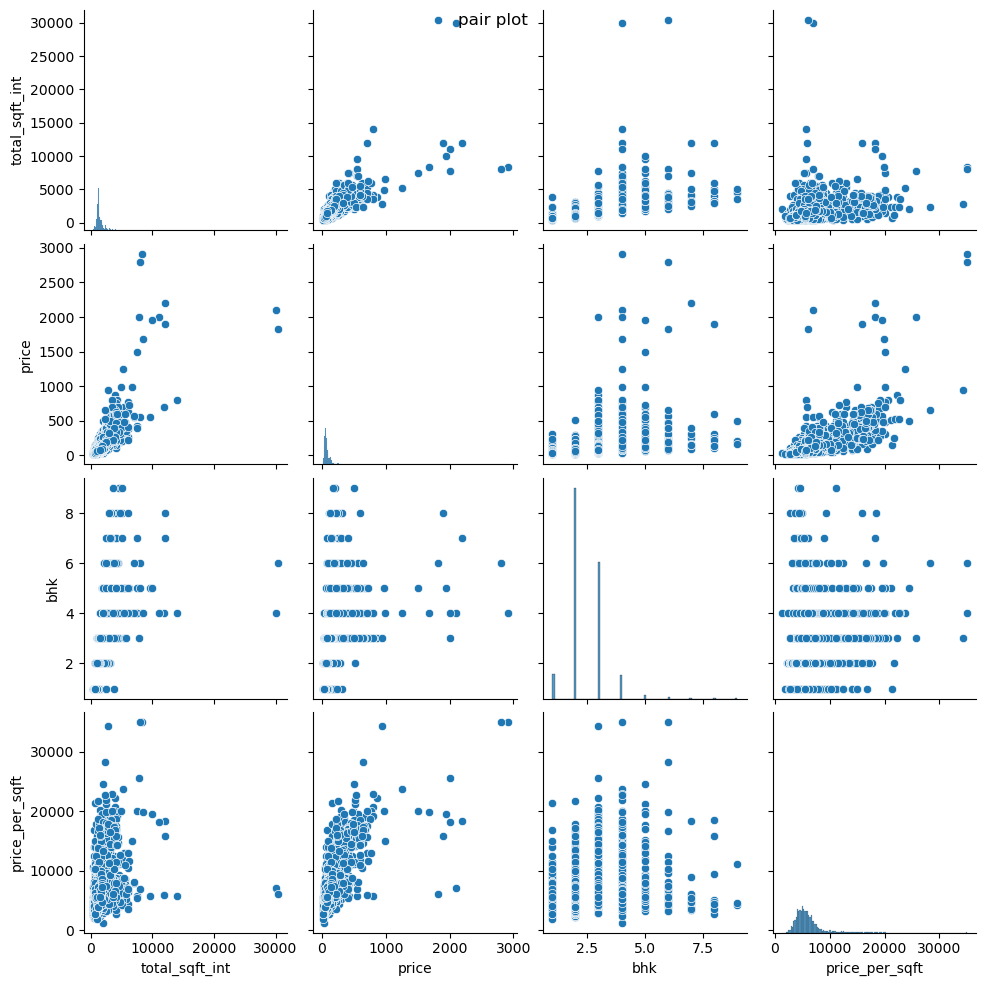

In [12]:
selected_columns = ['total_sqft_int', 'price', 'bhk', 'price_per_sqft']
sns.pairplot(df[selected_columns])
plt.suptitle('pair plot')
plt.savefig('pair_plot.png')
plt.show()

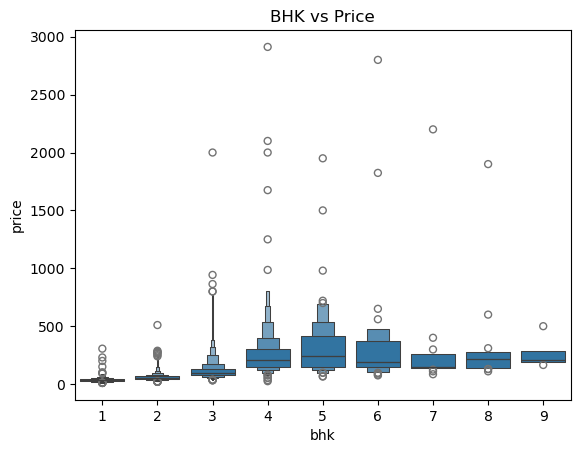

In [13]:
sns.boxenplot(x='bhk', y='price', data=df)
plt.title('BHK vs Price')
plt.savefig('box_plot.png')
plt.show()

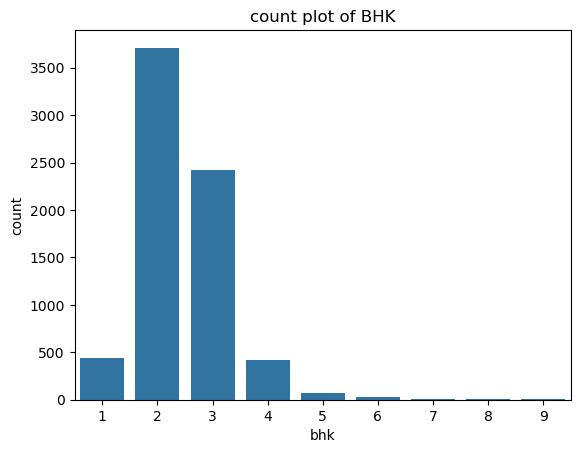

In [14]:
sns.countplot(x='bhk', data=df)
plt.title('count plot of BHK')
plt.savefig('count_plot.png')
plt.show()

In [15]:
df.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_type,Availability,location
0,3,2.0,150.0,1672.0,3,8971.291866,Super built-up Area,Ready To Move,Whitefield
1,3,3.0,149.0,1750.0,3,8514.285714,Built-up Area,Ready To Move,Whitefield
2,3,2.0,150.0,1750.0,3,8571.428571,Super built-up Area,Ready To Move,Whitefield
3,2,2.0,40.0,1250.0,2,3200.000000,Super built-up Area,Ready To Move,Whitefield
4,2,2.0,83.0,1200.0,2,6916.666667,Plot Area,Ready To Move,Whitefield


In [16]:
df.area_type.unique().sum()

'Super built-up  AreaBuilt-up  AreaPlot  Area'

In [17]:
ohe = OneHotEncoder()
ohe_area_type = ohe.fit(df[['area_type']])
ohe_area_type.categories_

[array(['Built-up  Area', 'Plot  Area', 'Super built-up  Area'],
       dtype=object)]

In [18]:
encoded_area_type = ohe.transform(df[['area_type']]).toarray()

In [19]:
df[['Built-up  Area', 'Plot  Area', 'Super built-up  Area']] = encoded_area_type

In [20]:
df = df.drop('area_type', axis=1)
df.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,Availability,location,Built-up Area,Plot Area,Super built-up Area
0,3,2.0,150.0,1672.0,3,8971.291866,Ready To Move,Whitefield,0.0,0.0,1.0
1,3,3.0,149.0,1750.0,3,8514.285714,Ready To Move,Whitefield,1.0,0.0,0.0
2,3,2.0,150.0,1750.0,3,8571.428571,Ready To Move,Whitefield,0.0,0.0,1.0
3,2,2.0,40.0,1250.0,2,3200.000000,Ready To Move,Whitefield,0.0,0.0,1.0
4,2,2.0,83.0,1200.0,2,6916.666667,Ready To Move,Whitefield,0.0,1.0,0.0


In [21]:
df = df.drop('Availability', axis=1)
df = df.drop('location', axis=1)

In [22]:
df.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,Built-up Area,Plot Area,Super built-up Area
0,3,2.0,150.0,1672.0,3,8971.291866,0.0,0.0,1.0
1,3,3.0,149.0,1750.0,3,8514.285714,1.0,0.0,0.0
2,3,2.0,150.0,1750.0,3,8571.428571,0.0,0.0,1.0
3,2,2.0,40.0,1250.0,2,3200.000000,0.0,0.0,1.0
4,2,2.0,83.0,1200.0,2,6916.666667,0.0,1.0,0.0


- KNei